HASIL KLASIFIKASI K-NN
              precision    recall  f1-score   support

           0       0.68      0.87      0.76        52
           1       0.46      0.22      0.30        27

    accuracy                           0.65        79
   macro avg       0.57      0.54      0.53        79
weighted avg       0.61      0.65      0.60        79



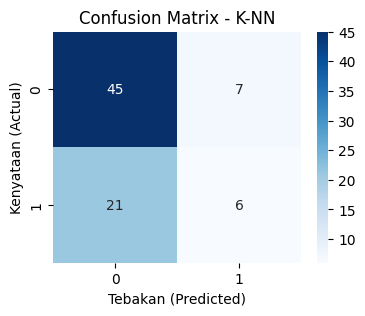

Akurasi K-NN: 0.6455696202531646


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

df = pd.read_excel('Book1.xlsx')
df['Label'] = np.where(df['G3'] < 10, 1, 0)
df_model = df.drop(['G1', 'G2', 'G3'], axis=1)
le = LabelEncoder()
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('Label', axis=1)
y = df_model['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)

print("HASIL KLASIFIKASI K-NN")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(4,3))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - K-NN')
plt.ylabel('Kenyataan (Actual)')
plt.xlabel('Tebakan (Predicted)')
plt.show()

print("Akurasi K-NN:", accuracy_score(y_test, y_pred_knn))